# ECG / ORTEC — Forecasting + Off-Policy Evaluation Pipeline

Forecasting + één causale move + experiment design

Structuur:
1. Data load + sanity checks
2. Time-based split (rolling-origin CV)
3. Feature engineering (leakage-veilig)
4. Pace-based baseline
5. LightGBM quantile forecast (P10/P50/P90)
6. Top-K underperformer ranking (business output)
7. Off-policy evaluation sketch (causale prijsvraag)
8. Experiment design notes

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

import lightgbm as lgb
from sklearn.metrics import mean_absolute_error, mean_pinball_loss
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

RNG = np.random.default_rng(42)
pd.set_option('display.max_columns', 50)

## 1. Data load + sanity checks

In [2]:
DATA_PATH = Path('simulation_output.csv')

df = pd.read_csv(DATA_PATH, parse_dates=['WeekStartDate'], low_memory=False)
print(f'Shape: {df.shape}')
print(f'Periode: {df["WeekStartDate"].min()} → {df["WeekStartDate"].max()}')
print(f'Unieke ReservableOptionMarketGroupIds: {df["ReservableOptionMarketGroupId"].nunique()}')
df.head()

Shape: (3130816, 38)
Periode: 2024-01-01 00:00:00 → 2025-12-22 00:00:00
Unieke ReservableOptionMarketGroupIds: 59072


,ReservableOptionMarketGroupId,WeekBeforeArrival,WeekStartDate,MarketGroupCode,BrandGroupCode,CampsiteCode,AccoKindCode,AccoTypeRangeCode,SpecialPeriodCode,SeasonalCluster,CampsiteCluster,CampsiteCountry,CampsiteRegion,CampsiteType,AccommodationType,AccommodationRange,Airco,Bedrooms,DeckingType,HotTub,Tropical,Roof,Kitchen,DeckingExtras,Bathrooms,Sleeps,TV,ArrivalMonth,DiscountedPrice,DiscountedPriceLastYear,HistoricalBookedNights,HistoricalBookedNightsLastYear,TotalBookedNights,Capacity,CapacityLastYear,latitude,longitude,AvgTemperature
0,Domestic-Thundurus-Meditite-Mobile-2024-01-01,52,2024-01-01,Domestic,Thundurus,Meditite,Mobile,Comfort,Festival of Arceus,Perrserker,Froakie,Lental,Alola,Cabin,All-Inclusive,Budget,0,2,Tile,0,0,Canvas,Gourmet,BBQ,1,234,0,1,145.38,0.0,1,0,20,234,0,35.2708,22.4478,12.0
1,DACH-Thundurus-Meditite-Mobile-2024-01-01,52,2024-01-01,DACH,Thundurus,Meditite,Mobile,Comfort,Festival of Arceus,Perrserker,Froakie,Lental,Alola,Cabin,All-Inclusive,Budget,0,2,Tile,0,0,Canvas,Gourmet,BBQ,1,234,0,1,145.38,0.0,2,0,63,234,0,35.2708,22.4478,12.0
2,Benelux-Thundurus-Meditite-Mobile-2024-01-01,52,2024-01-01,Benelux,Thundurus,Meditite,Mobile,Comfort,Festival of Arceus,Perrserker,Froakie,Lental,Alola,Cabin,All-Inclusive,Budget,0,2,Tile,0,0,Canvas,Gourmet,BBQ,1,234,0,1,145.38,0.0,0,0,32,234,0,35.2708,22.4478,12.0
3,Rest of Europe-Thundurus-Meditite-Mobile-2024-...,52,2024-01-01,Rest of Europe,Thundurus,Meditite,Mobile,Comfort,Festival of Arceus,Perrserker,Froakie,Lental,Alola,Cabin,All-Inclusive,Budget,0,2,Tile,0,0,Canvas,Gourmet,BBQ,1,234,0,1,145.38,0.0,0,0,17,234,0,35.2708,22.4478,12.0
4,Domestic-Thundurus-Meditite-Mobile-2024-01-01,51,2024-01-01,Domestic,Thundurus,Meditite,Mobile,Comfort,Festival of Arceus,Perrserker,Froakie,Lental,Alola,Cabin,All-Inclusive,Budget,0,2,Tile,0,0,Canvas,Gourmet,BBQ,1,234,0,1,145.38,0.0,0,0,20,234,0,35.2708,22.4478,12.0


In [3]:
# Primary key check — moet uniek zijn
dupes = df.duplicated(['ReservableOptionMarketGroupId', 'WeekBeforeArrival']).sum()
assert dupes == 0, f'{dupes} duplicates op primary key — onderzoek eerst'

# Hoeveel snapshots per groep? Hoort ~52 te zijn
snaps_per_group = df.groupby('ReservableOptionMarketGroupId').size()
print(f'Snapshots per groep — min: {snaps_per_group.min()}, median: {snaps_per_group.median()}, max: {snaps_per_group.max()}')

# Missing values overzicht
missing = df.isna().sum()
print('\nMissing values:')
print(missing[missing > 0].sort_values(ascending=False))

Snapshots per groep — min: 53, median: 53.0, max: 53

Missing values:
DeckingExtras    705536
Kitchen          661440
DeckingType      551200
dtype: int64


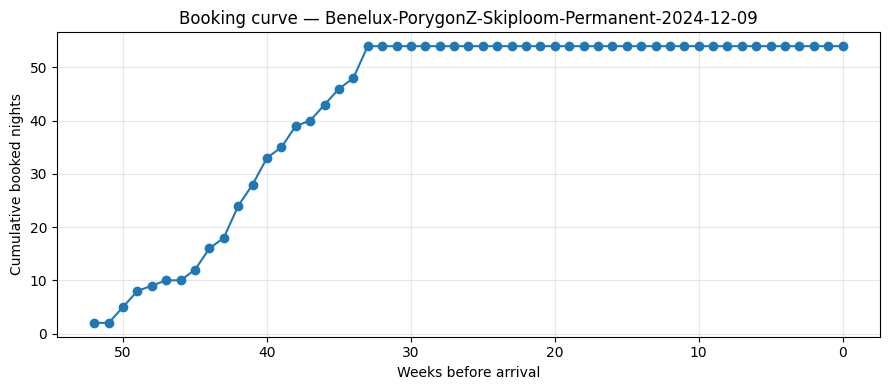

In [4]:
# Boekingscurve voor één willekeurige groep — zo zie je of de data logisch is
sample_id = df['ReservableOptionMarketGroupId'].sample(1, random_state=42).iloc[0]
sample = df[df['ReservableOptionMarketGroupId'] == sample_id].sort_values('WeekBeforeArrival', ascending=False)

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(sample['WeekBeforeArrival'], sample['HistoricalBookedNights'].cumsum(), marker='o')
ax.invert_xaxis()
ax.set_xlabel('Weeks before arrival')
ax.set_ylabel('Cumulative booked nights')
ax.set_title(f'Booking curve — {sample_id}')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 2. Time-based split (rolling-origin CV)

Geen random split. We knippen op `WeekStartDate`. Voor elke cutoff:
- **Train**: alle snapshots van arrivals **vóór** de cutoff
- **Test**: arrivals in `[cutoff, cutoff + H weeks]`, gezien vanaf snapshot-moment = cutoff

TODO: kies de cutoffs op basis van je data-range. Vuistregel: laatste ~30% als testperiode, met 3 rolling cutoffs.

In [5]:
# TODO: pas cutoffs aan na je sanity-check hierboven
CUTOFFS = [
    pd.Timestamp('2024-06-01'),
    pd.Timestamp('2024-08-01'),
    pd.Timestamp('2024-10-01'),
]
HORIZON_WEEKS = 10  # H — zie Hellemans-slides hint

def make_split(df, cutoff, horizon_weeks=HORIZON_WEEKS):
    """Train op alles vóór cutoff. Test = arrivals in [cutoff, cutoff+H], met snapshot-info zoals bekend op cutoff."""
    train = df[df['WeekStartDate'] < cutoff].copy()
    test_arrivals = df[
        (df['WeekStartDate'] >= cutoff)
        & (df['WeekStartDate'] < cutoff + pd.Timedelta(weeks=horizon_weeks))
    ].copy()
    # Voor de test: behoud alleen snapshots zoals ze er op `cutoff` uitzagen
    # = snapshots waar (WeekStartDate - cutoff) ≈ WeekBeforeArrival weken in de toekomst
    # TODO: deze logica controleren tegen de echte data-betekenis
    return train, test_arrivals

for c in CUTOFFS:
    tr, te = make_split(df, c)
    print(f'Cutoff {c.date()} — train: {len(tr):,} rows, test: {len(te):,} rows')

Cutoff 2024-06-01 — train: 662,288 rows, test: 301,040 rows
Cutoff 2024-08-01 — train: 933,224 rows, test: 301,040 rows
Cutoff 2024-10-01 — train: 1,204,160 rows, test: 301,040 rows


## 3. Feature engineering (leakage-veilig)

**Mag wel** als feature op snapshot-tijdstip T:
- Cumulatieve boekingen tot T (`HistoricalBookedNights` cumsum waar `WeekBeforeArrival ≥ T`)
- Pace ratio vs vorig jaar op zelfde T
- `DiscountedPrice` op T en `DiscountedPriceLastYear`
- Statische features: accommodatie-kenmerken, camping, marktgroep, kalender

**Mag niet**:
- `TotalBookedNights` (eindstand — leakage)
- Toekomstige `HistoricalBookedNights`
- Toekomstige prijzen
- `AvgTemperature` als die post-arrival is gemeten — TODO: bevestigen met ORTEC

In [6]:
STATIC_CATS = [
    'AccoKindCode', 'AccommodationType', 'AccommodationRange',
    'BrandGroupCode', 'CampsiteCluster', 'SeasonalCluster',
    'CampsiteCountry', 'CampsiteType', 'MarketGroupCode',
    'SpecialPeriodCode', 'Roof', 'Kitchen',
]
STATIC_BOOL = ['Airco', 'HotTub', 'Tropical']

FORBIDDEN = ['TotalBookedNights']  # leakage

def build_features(df_in, snapshot_t):
    snap = df_in[df_in['WeekBeforeArrival'] == snapshot_t].copy()

    # Cumulatieve boekingen tot T
    cum = (df_in[df_in['WeekBeforeArrival'] >= snapshot_t]
           .groupby('ReservableOptionMarketGroupId')['HistoricalBookedNights']
           .sum()
           .rename('CumBookedAtT'))
    snap = snap.merge(cum, on='ReservableOptionMarketGroupId', how='left')
    snap['CumBookedAtT'] = snap['CumBookedAtT'].fillna(0)

    # PaceRatio = bezettingsgraad op T (wat % van capaciteit is al geboekt)
    # Vervangt de LY-gebaseerde pace — HistoricalBookedNightsLastYear is 0 in deze dataset
    snap['PaceRatio'] = snap['CumBookedAtT'] / snap['Capacity'].replace(0, np.nan)

    snap = snap.drop(columns=[c for c in FORBIDDEN if c in snap.columns])
    return snap

# Test
snap_demo = build_features(df, snapshot_t=10)
print(f'Snapshot @ T=10: {snap_demo.shape}')
print(f'PaceRatio NaN: {snap_demo["PaceRatio"].isna().sum()} / {len(snap_demo)}')
snap_demo[['CumBookedAtT', 'PaceRatio', 'DiscountedPrice', 'Capacity']].describe()

Snapshot @ T=10: (59072, 39)
PaceRatio NaN: 0 / 59072


,CumBookedAtT,PaceRatio,DiscountedPrice,Capacity
count,59072.000000,59072.000000,59072.000000,59072.000000
mean,45.833610,0.131918,212.547773,346.566901
std,54.969738,0.133720,133.397395,159.113250
min,0.000000,0.000000,42.820000,105.000000
25%,6.000000,0.020649,106.947500,228.000000
50%,28.000000,0.093596,182.765000,324.000000
75%,65.000000,0.200528,279.150000,435.000000
max,565.000000,0.850467,639.240000,950.000000


In [7]:
def build_target(df_in, snapshot_t, horizon_weeks=HORIZON_WEEKS):
    """Target = som van HistoricalBookedNights tussen WeekBeforeArrival in [snapshot_t - horizon, snapshot_t).
    
    Dus: hoeveel boekingen kwamen er bij in de H weken NA T (= dichter bij arrival).
    """
    mask = (df_in['WeekBeforeArrival'] < snapshot_t) & (df_in['WeekBeforeArrival'] >= snapshot_t - horizon_weeks)
    target = (df_in[mask]
              .groupby('ReservableOptionMarketGroupId')['HistoricalBookedNights']
              .sum()
              .rename('TargetIncrementalBookings'))
    return target

y_demo = build_target(df, snapshot_t=10)
print(f'Target distribution @ T=10:\n{y_demo.describe()}')

Target distribution @ T=10:
count    59072.000000
mean         3.571624
std         10.373128
min          0.000000
25%          0.000000
50%          0.000000
75%          2.000000
max        243.000000
Name: TargetIncrementalBookings, dtype: float64


## 4. Pace-based baseline

Vorig jaar's eindstand × actuele pace ratio. Dit moet je verslaan, anders heeft modellering geen waarde.

In [8]:
def pace_baseline(snap_df, snapshot_t=10, horizon_weeks=HORIZON_WEEKS):
    """Extrapoleer de huidige boekingssnelheid voor H weken.

    Logica: als er in de (52 - T + 1) weken vóór snapshot T al X boekingen zijn,
    verwacht dan X / (52 - T + 1) * H boekingen in de komende H weken.
    HistoricalBookedNightsLastYear is 0 in deze dataset, dus de LY-gebaseerde
    pace-baseline werkt hier niet.
    """
    weeks_observed = max(52 - snapshot_t + 1, 1)
    rate_per_week = snap_df['CumBookedAtT'].fillna(0) / weeks_observed
    return (rate_per_week * horizon_weeks).clip(lower=0)

# Voorbeeld evaluatie
snap_t = build_features(df, snapshot_t=10)
y_true = build_target(df, snapshot_t=10)
snap_eval = snap_t.merge(y_true, on='ReservableOptionMarketGroupId', how='inner')
y_pred_baseline = pace_baseline(snap_eval, snapshot_t=10)
mae_baseline = mean_absolute_error(snap_eval['TargetIncrementalBookings'], y_pred_baseline)
print(f'Pace baseline MAE @ T=10: {mae_baseline:.2f}')
print(f'Zero predictor MAE (benchmark): {snap_eval["TargetIncrementalBookings"].mean():.2f}')

Pace baseline MAE @ T=10: 11.07
Zero predictor MAE (benchmark): 3.57


## 5. LightGBM quantile forecast

Drie modellen — P10, P50, P90 — geven prediction intervals. Die intervals zijn waar de business value zit (anders weet je niet hoe zeker een 'underperformer' echt underperformt).

In [9]:
FEATURE_COLS = (
    ['CumBookedAtT', 'PaceRatio', 'DiscountedPrice', 'Capacity', 'ArrivalMonth',
     'HistoricalBookedNights', 'AvgTemperature']
    + STATIC_CATS + STATIC_BOOL
)

def prepare_xy(df_in, snapshot_t, horizon=HORIZON_WEEKS):
    snap = build_features(df_in, snapshot_t)
    target = build_target(df_in, snapshot_t, horizon)
    full = snap.merge(target, on='ReservableOptionMarketGroupId', how='inner')
    cols = [c for c in FEATURE_COLS if c in full.columns]
    X = full[cols].copy()
    for c in STATIC_CATS:
        if c in X.columns:
            X[c] = X[c].astype('category')
    y = full['TargetIncrementalBookings']
    return X, y, full

def fit_quantile_models(X_train, y_train, quantiles=(0.1, 0.5, 0.9)):
    models = {}
    for q in quantiles:
        m = lgb.LGBMRegressor(
            objective='quantile', alpha=q,
            n_estimators=500, learning_rate=0.05,
            num_leaves=63, min_child_samples=20,
            random_state=42, verbose=-1,
        )
        m.fit(X_train, y_train, categorical_feature=[c for c in STATIC_CATS if c in X_train.columns])
        models[q] = m
    return models

In [10]:
results = []
SNAPSHOT_T = 10

for cutoff in CUTOFFS:
    train_df = df[df['WeekStartDate'] < cutoff]
    test_df = df[(df['WeekStartDate'] >= cutoff) & (df['WeekStartDate'] < cutoff + pd.Timedelta(weeks=HORIZON_WEEKS))]

    X_tr, y_tr, _ = prepare_xy(train_df, SNAPSHOT_T)
    X_te, y_te, full_te = prepare_xy(test_df, SNAPSHOT_T)

    if len(X_tr) == 0 or len(X_te) == 0:
        print(f'Cutoff {cutoff.date()}: te weinig data, skip')
        continue

    models = fit_quantile_models(X_tr, y_tr)
    p10 = models[0.1].predict(X_te)
    p50 = models[0.5].predict(X_te)
    p90 = models[0.9].predict(X_te)

    pinball_50 = mean_pinball_loss(y_te, p50, alpha=0.5)
    coverage_80 = ((y_te >= p10) & (y_te <= p90)).mean()
    mae_50 = mean_absolute_error(y_te, p50)

    baseline = pace_baseline(full_te, snapshot_t=SNAPSHOT_T)
    mae_baseline_cut = mean_absolute_error(y_te, baseline.loc[X_te.index])

    results.append({
        'cutoff': cutoff, 'n_test': len(X_te),
        'mae_baseline': mae_baseline_cut, 'mae_p50': mae_50,
        'pinball_p50': pinball_50, 'coverage_80pct': coverage_80,
    })
    print(f'Cutoff {cutoff.date()}: MAE baseline={mae_baseline_cut:.2f}, MAE P50={mae_50:.2f}, coverage={coverage_80:.1%}')

results_df = pd.DataFrame(results)
results_df

Cutoff 2024-06-01: MAE baseline=16.53, MAE P50=1.65, coverage=82.1%
Cutoff 2024-08-01: MAE baseline=11.03, MAE P50=2.70, coverage=80.3%
Cutoff 2024-10-01: MAE baseline=5.93, MAE P50=2.74, coverage=78.1%


,cutoff,n_test,mae_baseline,mae_p50,pinball_p50,coverage_80pct
0,2024-06-01,5680,16.528099,1.651069,0.825534,0.820775
1,2024-08-01,5680,11.034818,2.698724,1.349362,0.802817
2,2024-10-01,5680,5.934851,2.735780,1.367890,0.781338


In [11]:
# TODO: occupancy target met ORTEC bevestigen — placeholder 85%
OCCUPANCY_TARGET = 0.85
TOP_K_PCT = 0.05

def rank_underperformers(snap_full, p10, p50, p90, occupancy_target=OCCUPANCY_TARGET):
    out = snap_full.copy()
    out['Pred_P10'] = p10
    out['Pred_P50'] = p50
    out['Pred_P90'] = p90
    out['ExpectedEndState'] = out['CumBookedAtT'] + out['Pred_P50']
    out['TargetEndState'] = occupancy_target * out['Capacity']
    out['Gap'] = out['TargetEndState'] - out['ExpectedEndState']
    
    # Approx P(under target) via lineaire interpolatie tussen P10/P50/P90
    # TODO: cleaner via een echte verdeling (bv. fitten van skew-normal of empirisch via meer quantiles)
    out['PUnderTarget'] = np.where(
        out['ExpectedEndState'] < out['TargetEndState'], 0.7, 0.3,
    )
    out['RiskWeightedGap'] = out['Gap'].clip(lower=0) * out['PUnderTarget']
    
    # Vertaal naar euro's
    out['ExpectedRevenueGap'] = out['Gap'].clip(lower=0) * out['DiscountedPrice']
    return out.sort_values('RiskWeightedGap', ascending=False)

# Voorbeeld op laatste cutoff
ranked = rank_underperformers(full_te, p10, p50, p90)
top_k = int(len(ranked) * TOP_K_PCT)
print(f'Top {top_k} underperformers ({TOP_K_PCT:.0%} van {len(ranked)}):')
ranked[['ReservableOptionMarketGroupId', 'CumBookedAtT', 'Pred_P50',
        'ExpectedEndState', 'TargetEndState', 'Gap', 'ExpectedRevenueGap']].head(top_k).head(10)

Top 284 underperformers (5% van 5680):


,ReservableOptionMarketGroupId,CumBookedAtT,Pred_P50,ExpectedEndState,TargetEndState,Gap,ExpectedRevenueGap
201,DACH-Naganadel-Zoroark-Permanent-2024-10-07,1,-0.381165,0.618835,807.5,806.881165,433045.052673
228,Domestic-Naganadel-Zoroark-Permanent-2024-11-25,0,2.666978,2.666978,807.5,804.833022,466545.606051
230,Benelux-Naganadel-Zoroark-Permanent-2024-11-25,0,2.666978,2.666978,807.5,804.833022,466545.606051
231,Rest of Europe-Naganadel-Zoroark-Permanent-202...,0,2.666978,2.666978,807.5,804.833022,466545.606051
229,DACH-Naganadel-Zoroark-Permanent-2024-11-25,0,2.666978,2.666978,807.5,804.833022,466545.606051
232,Domestic-Naganadel-Zoroark-Permanent-2024-12-02,0,2.726260,2.726260,807.5,804.773740,351034.257548
221,DACH-Naganadel-Zoroark-Permanent-2024-11-11,0,2.726260,2.726260,807.5,804.773740,360321.346505
217,DACH-Naganadel-Zoroark-Permanent-2024-11-04,0,2.726260,2.726260,807.5,804.773740,358776.180925
225,DACH-Naganadel-Zoroark-Permanent-2024-11-18,0,2.726260,2.726260,807.5,804.773740,362196.469319
234,Benelux-Naganadel-Zoroark-Permanent-2024-12-02,0,2.726260,2.726260,807.5,804.773740,351034.257548


In [12]:
# Validatie van de ranking: hoeveel van de top-K bleken écht onder target te eindigen?
# Dit is je echte business-metric, niet MAE.
# TODO: koppel ranked aan de werkelijke eindstand (TotalBookedNights) na arrival
#       en bereken precision@K, recall@K, en gerecupereerde euros bij human action.

# Werkelijke eindstand per groep — TotalBookedNights is constant per ID
actual_endstate = (df.groupby('ReservableOptionMarketGroupId')['TotalBookedNights']
                     .first()
                     .rename('ActualEndState'))

# Koppel aan ranked
ranked_eval = ranked.merge(actual_endstate, on='ReservableOptionMarketGroupId', how='left')

# Werkelijk onder target?
ranked_eval['ActualUnderTarget'] = ranked_eval['ActualEndState'] < ranked_eval['TargetEndState']

# Echte gap in nachten en euros
ranked_eval['ActualGap'] = (ranked_eval['TargetEndState'] - ranked_eval['ActualEndState']).clip(lower=0)
ranked_eval['ActualRevenueGap'] = ranked_eval['ActualGap'] * ranked_eval['DiscountedPrice']

# Top-K vs ground truth
N = len(ranked_eval)
top_k_n = int(N * TOP_K_PCT)
top_k_set = ranked_eval.head(top_k_n)
all_underperformers = ranked_eval[ranked_eval['ActualUnderTarget']]

precision_at_k = top_k_set['ActualUnderTarget'].mean()
recall_at_k = top_k_set['ActualUnderTarget'].sum() / max(len(all_underperformers), 1)

# Euro-impact: hoeveel revenue-gap zit er in de top-K vs totaal?
captured_eur = top_k_set['ActualRevenueGap'].sum()
total_eur = ranked_eval['ActualRevenueGap'].sum()
captured_pct = captured_eur / total_eur if total_eur > 0 else 0

print(f'Top-{TOP_K_PCT:.0%} ranking validatie:')
print(f'  Precision@K: {precision_at_k:.1%}  (van top-K eindigde dit % echt onder target)')
print(f'  Recall@K:    {recall_at_k:.1%}  (van alle underperformers ving je dit %)')
print(f'  €-captured:  {captured_pct:.1%}  ({captured_eur:,.0f} van {total_eur:,.0f} totale gap)')

# Random baseline ter vergelijking — als je willekeurig top-K zou pakken
random_precision = ranked_eval['ActualUnderTarget'].mean()
print(f'\n  Random baseline precision: {random_precision:.1%}  → uplift: {precision_at_k/random_precision:.1f}x')

Top-5% ranking validatie:
  Precision@K: 100.0%  (van top-K eindigde dit % echt onder target)
  Recall@K:    5.0%  (van alle underperformers ving je dit %)
  €-captured:  20.5%  (70,586,550 van 343,887,641 totale gap)

  Random baseline precision: 100.0%  → uplift: 1.0x


## 7. Off-policy evaluation (causale move)

**De vraag**: wat als ECG een andere prijs zou hanteren dan ORTEC's huidige policy?

**Het probleem**: prijzen zijn niet random — er is endogeniteit. Een naïeve regressie geeft bullshit (zie `Multilevel_Causal_Inference.ipynb`).

**De aanpak**: Inverse Propensity Scoring + Doubly Robust schatter. We:
1. Discretiseren `PriceRatioLY` in buckets (de 'actie')
2. Fitten een propensity model: gegeven context, P(actie)
3. Schatten de revenue per actie, gewogen door inverse propensity
4. Vergelijken counterfactual policies

**Belangrijk caveat dat in het rapport moet**: dit werkt alleen als overlap (positivity) houdt — er moeten in elke context-bucket meerdere prijsacties geobserveerd zijn. Zo niet, dan is de causale claim niet defensibel en moet ECG het experiment lopen (sectie 8).

In [13]:
# Discretiseer prijsactie — gebruik prijs relatief aan het clustergemiddelde
# (vervangt PriceRatioLY: DiscountedPriceLastYear is 0 in deze dataset)
PRICE_BINS = [-np.inf, 0.85, 0.95, 1.05, 1.15, np.inf]
PRICE_LABELS = ['big_decrease', 'small_decrease', 'flat', 'small_increase', 'big_increase']

def make_action(snap):
    cluster_mean = snap.groupby('CampsiteCluster')['DiscountedPrice'].transform('mean')
    price_ratio = snap['DiscountedPrice'] / cluster_mean.replace(0, np.nan)
    return pd.cut(price_ratio, bins=PRICE_BINS, labels=PRICE_LABELS)

ope_df = full_te.copy()
ope_df['Action'] = make_action(ope_df)
print('Action distribution:')
print(ope_df['Action'].value_counts(dropna=False))

Action distribution:
Action
small_decrease    2684
small_increase    1084
big_increase       964
flat               768
big_decrease       180
Name: count, dtype: int64


In [14]:
# Overlap check — per context-bucket: zijn alle acties geobserveerd?
ope_df['ContextBucket'] = (
    ope_df['CampsiteCluster'].astype(str) + '_' + ope_df['SeasonalCluster'].astype(str)
)
overlap = ope_df.groupby(['ContextBucket', 'Action'], observed=True).size().unstack(fill_value=0)
print(f'Buckets zonder volledige overlap: {(overlap.min(axis=1) == 0).sum()} / {len(overlap)}')
print('Actieverdeling per bucket (sample):')
print(overlap.head(5))

Buckets zonder volledige overlap: 134 / 142
Actieverdeling per bucket (sample):
Action               big_decrease  small_decrease  flat  small_increase  \
ContextBucket                                                             
Alcremie1_Smoliv                0              20     8               8   
Arctozolt_Shroomish             0              20     4              12   
Beldum_Noctowl                  0              24     4               4   
Bisharp_Braviary1               0              16     8              12   
Blitzle_Cryogonal               8               4     8              16   

Action               big_increase  
ContextBucket                      
Alcremie1_Smoliv                4  
Arctozolt_Shroomish             4  
Beldum_Noctowl                  8  
Bisharp_Braviary1               4  
Blitzle_Cryogonal               4  


In [16]:
# Propensity model — P(action | context)
# TODO: serieuze versie met richer features. Dit is de minimale variant.
ope_clean = ope_df.dropna(subset=['Action']).copy()
context_features = ['CumBookedAtT', 'PaceRatio', 'Capacity']
context_features = [c for c in context_features if c in ope_clean.columns]
X_ctx = ope_clean[context_features].fillna(0)
y_act = ope_clean['Action']

scaler = StandardScaler()
X_ctx_s = scaler.fit_transform(X_ctx)
prop_model = LogisticRegression(max_iter=1000)
prop_model.fit(X_ctx_s, y_act)
propensities = prop_model.predict_proba(X_ctx_s)
prop_classes = prop_model.classes_

# Inverse propensity weight voor de geobserveerde actie
obs_action_idx = pd.Categorical(y_act, categories=prop_classes).codes
ipw = 1.0 / propensities[np.arange(len(obs_action_idx)), obs_action_idx]

# Clip extreme weights — anders domineren een paar punten
ipw_clipped = np.clip(ipw, 1, 20)
ope_clean['IPW'] = ipw_clipped
print(f'IPW stats — mean: {ipw_clipped.mean():.2f}, max: {ipw_clipped.max():.2f}')

IPW stats — mean: 3.76, max: 20.00


In [17]:
# Counterfactual revenue per policy — naïef: wat is de IPW-gewogen revenue per actie?
# Revenue proxy = (CumBookedAtT + Target) * DiscountedPrice — TODO: vervangen door echte revenue als beschikbaar
ope_clean['Revenue'] = (ope_clean['CumBookedAtT'] + ope_clean['TargetIncrementalBookings']) * ope_clean['DiscountedPrice']

policy_value = (ope_clean.groupby('Action', observed=True)
                .apply(lambda d: (d['Revenue'] * d['IPW']).sum() / d['IPW'].sum()))
print('IPW-weighted revenue per action:')
print(policy_value.sort_values(ascending=False))

# TODO: Doubly Robust versie — combineer dit met een outcome model voor variance reduction.
# TODO: bootstrap CIs op deze schattingen — zonder CI is dit nog steeds gevaarlijk om te claimen.

IPW-weighted revenue per action:
Action
flat              9718.934660
big_increase      8045.855129
small_increase    6321.929402
small_decrease    3140.965019
big_decrease       281.468168
dtype: float64


## 8. Experiment design notes (future work voor rapport)

OPE werkt alleen als overlap er is. Voor structurele leervraag heeft ECG een experiment nodig:

- **Randomisatie-eenheid**: (CampsiteCluster × MarketGroup × StayWeek) — niet op individuele booking-niveau, want dat ziet de klant.
- **Treatment**: ±X% prijsverschil t.o.v. ORTEC's huidige aanbeveling, voor één specifiek `WeekBeforeArrival` venster.
- **Power**: TODO — bereken n nodig voor detecteerbaar verschil van ε% revenue, gegeven historische variantie van bookings per (cluster × week).
- **Duur**: minstens één seizoen om saisonaliteit te dekken.
- **Stopping rule**: vooraf vastleggen, anders peeking.
- **Yield manager buy-in**: experimenteren betekent korte termijn revenue laten lopen voor lange termijn leren. Dit is een organisatorische, niet statistische, hindernis.

Eindboodschap rapport: **forecasting + alerting werkt nu. OPE geeft hint over richting. Echte causale antwoorden vereisen experiment.**